Import Necessary Libraries

Python

Environment Setup

This notebook relies on standard data science libraries for data manipulation and path handling.

In [24]:
import pandas as pd
import os  # <--- This line fixes your error!

# Now Python knows what 'os' is, and this will work perfectly:
raw_data_folder = os.path.join('data', 'raw') 
sales_data_path = os.path.join(raw_data_folder, 'retail_sales.csv')
inventory_data_path = os.path.join(raw_data_folder, 'inventory_levels.csv')

print("Paths configured correctly!")

Paths configured correctly!


### Exploring the `os.path` Library

Before constructing our file paths, we can inspect the `os.path.join` tool. 

In Python, calling a function's name without parentheses returns the function object itself rather than executing it. This confirms the tool is loaded and ready to accept our folder and file names.

In [22]:
os.path.join

<function ntpath.join(path, *paths)>

### File Path Configuration

Next, we define the locations of our raw datasets. 

Instead of hard-coding the exact folder structure, we use the `os.path.join()` function. This is a standard Python best practice that ensures our code is fully cross-platform. Whether this notebook is opened on a Windows, Mac, or Linux machine, `os.path` will automatically use the correct slash separators to find the files.

*(Note: The raw CSV files are stored locally in the `data/raw` folder. Following best practices, these specific files are excluded via `.gitignore` to keep the repository lightweight.)*

In [23]:
# Define paths to raw data files
# Note: In a real project, ensure these files are ignored in .gitignore!
raw_data_folder = 'data/raw'
sales_data_path = os.path.join(raw_data_folder, 'retail_sales.csv')
inventory_data_path = os.path.join(raw_data_folder, 'inventory_levels.csv')

print(f"Sales data path: {sales_data_path}")
print(f"Inventory data path: {inventory_data_path}")

Sales data path: data/raw\retail_sales.csv
Inventory data path: data/raw\inventory_levels.csv


### Loading the Primary Dataset

With our environment set up and paths understood, we will now load the main Olist retail sales dataset into a Pandas DataFrame. 

To ensure the code runs smoothly on this Windows machine, we use a "raw string" (indicated by the `r` before the quotes) to correctly parse the backslashes in the file path. We have also wrapped the loading function in a `try...except` block. This is a standard defensive programming practice that will catch and clearly report a `FileNotFoundError` if the CSV is ever moved or renamed.

In [16]:
# Notice the 'r' at the beginning, the quotes, and the specific .csv file at the end
sales_data_path = r"D:\Infotact Solutions\First Project GitHub File\Retail-Sales-Inventory-Analytics\Retail-Sales-Inventory-Analytics\Brazilian E-Commerce Public Dataset by Olist\raw_data_df.csv"

# Now load the data
try:
    sales_df = pd.read_csv(r"D:\Infotact Solutions\First Project GitHub File\Retail-Sales-Inventory-Analytics\Retail-Sales-Inventory-Analytics\Brazilian E-Commerce Public Dataset by Olist\raw_data_df.csv")
    print("Successfully loaded retail sales data!")
except FileNotFoundError:
    print("Error: File not found. Double-check the exact spelling of the file name.")

Successfully loaded retail sales data!


### Initial Data Inspection

Before we can clean or analyze the data, we must understand its structure. 

We use the `.head()` function to print the first 5 rows of our dataset. This allows us to perform a visual sanity check, confirm that our column headers loaded correctly, and see what the raw data entries look like (e.g., checking if dates look like actual dates or if IDs are alphanumeric strings).

In [17]:
# Look at the first 5 rows to understand what the data looks like
sales_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00


### Validating Data Types and Completeness

Next, we run `.info()` to generate a structural summary of the dataframe. This allows us to check two vital aspects of data health:
1.  **Missing Values (Nulls):** By comparing the `Non-Null Count` of each column against the total `RangeIndex`, we can quickly spot which columns have missing data.
2.  **Data Types (Dtypes):** We must ensure numerical data is recognized as numbers (int/float) and dates are recognized as Datetime objects, not just plain text.

In [18]:
# Check column data types (e.g., are dates actually formatted as dates, or as text?)
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


### Quantifying Missing Data

Having identified that missing values exist, we need to know the exact extent of the issue. By chaining `.isnull()` with `.sum()`, we calculate the total count of `NULL` (missing) values for every single column. This will dictate our data cleaning strategy.

In [19]:
# Count exactly how many missing values exist in each individual column
sales_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## Identifying Duplicate Records

The final step in our initial data audit is to check for duplicate rows. Duplicate transactions are dangerous because they can artificially inflate revenue calculations and skew inventory metrics. We use `.duplicated().sum()` to scan the entire dataframe for any rows that are exact, 1-to-1 copies of another.

In [20]:
# Count the number of exact duplicate rows in the entire dataset
sales_df.duplicated().sum()

np.int64(0)

### Statistical Summary & Categorical Analysis

To understand the distribution of our text-based and categorical columns, we generate a descriptive statistics summary. 

*(Note: Because our previous `.info()` check revealed that all columns are currently loaded as text strings, the standard numerical summary will default to a categorical summary until we convert our prices/dates to their proper data types).*

In [27]:
# 1. Statistical summary for numerical columns
display(sales_df.describe())

# 2. Summary for categorical and text columns
display(sales_df.describe(include=['object', 'str']))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,88789,50462,61544,75649,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8/2/2018 12:06,1/10/2018 10:32,5/9/2018 15:48,12/11/2017 18:52,12/20/2017 0:00
freq,1,1,96478,28,109,47,7,522


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,88789,50462,61544,75649,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8/2/2018 12:06,1/10/2018 10:32,5/9/2018 15:48,12/11/2017 18:52,12/20/2017 0:00
freq,1,1,96478,28,109,47,7,522


## Exploratory Data Analysis (EDA)

With our data successfully loaded and audited, we now transition into the Exploratory Data Analysis (EDA) phase. Our goal here is to visualize the data to uncover trends, distributions, and potential anomalies in our retail sales.

### Visualization Environment Setup

First, we import the industry-standard visualization libraries in Python: `matplotlib` and `seaborn`. We also configure a global visual theme (`whitegrid`) to ensure all of our upcoming charts are clean, consistent, and easy for the team to read.

In [48]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a visual theme for your notebook
sns.set_theme(style="whitegrid")

### Verifying Available Data for Visualization

Before we begin constructing our plots, we print a quick list of all available column names in our `sales_df` dataframe. This serves as a handy reference guide to ensure we use the exact spelling for the variables we want to analyze.

In [32]:
# This will print out a list of every column name in your dataset
list(sales_df.columns)

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

### Visualizing Order Status Distribution

To begin our Exploratory Data Analysis, we will look at the overall health of our order pipeline. 

Because `order_status` is a categorical variable, we use a Seaborn `countplot`. This will automatically calculate the frequencies of each status and plot them as a bar chart, giving us an immediate visual understanding of our fulfillment success rate. We rotate the x-axis labels by 45 degrees to ensure the status names do not overlap.

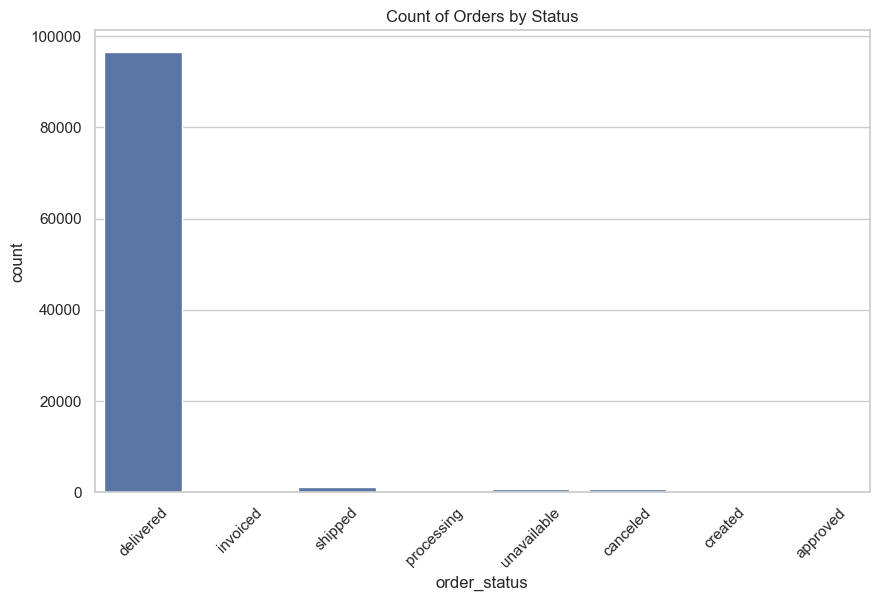

In [35]:
plt.figure(figsize=(10, 6))
# This uses the 'order_status' column which DOES exist in your dataframe
sns.countplot(data=sales_df, x='order_status') 
plt.title('Count of Orders by Status')
plt.xticks(rotation=45)
plt.show()

### Environment Verification: Current Working Directory

To ensure our file paths are resolving correctly, we can verify exactly which directory Python is operating from. 

We use `os.getcwd()` to print the Current Working Directory. We then use `os.listdir()` to print a list of all files and folders visible to Python in that exact location. This is a critical debugging step to ensure Python is looking in the correct project folder before we attempt to load additional datasets.

In [39]:
import os

# This prints exactly which folder Python is currently looking at
print("Current Folder:", os.getcwd())

# This lists every file Python can see in this folder
print("\nFiles in this folder:")
for file in os.listdir():
    print("-", file)

Current Folder: D:\Infotact Solutions\First Project GitHub File\Retail-Sales-Inventory-Analytics\Retail-Sales-Inventory-Analytics

Files in this folder:
- .ipynb_checkpoints
- 01_load_data.ipynb
- Brazilian E-Commerce Public Dataset by Olist
- venv


## Phase 2: Payments Dataset Analysis

Having audited our primary sales data, we now bring in the **Order Payments** dataset to understand customer spending behaviors and transaction methods.

### Loading and Visualizing Payment Distribution

We will load the payments CSV and immediately visualize the `payment_value` column. To do this, we use a Seaborn `histplot` (histogram). 
* We set `bins=30` to group the transaction amounts into 30 distinct buckets.
* We set `kde=True` (Kernel Density Estimate) to draw a smooth curve over the bars, making it easier to see the overall shape of the spending distribution.

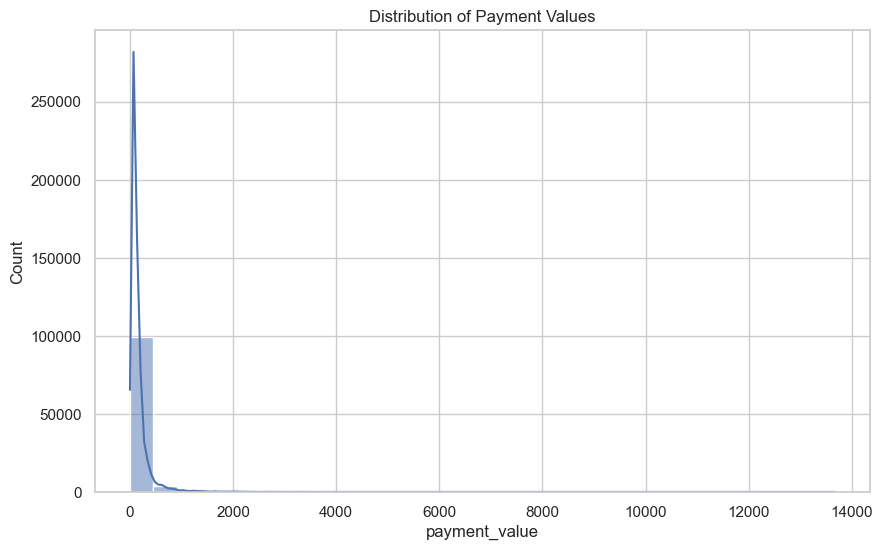

In [40]:
# 1. Load the data by pointing Python to the correct sub-folder
payments_df = pd.read_csv('Brazilian E-Commerce Public Dataset by Olist/olist_order_payments_dataset.csv')

# 2. Plot the payment values
plt.figure(figsize=(10, 6))
sns.histplot(payments_df['payment_value'], kde=True, bins=30) 
plt.title('Distribution of Payment Values')
plt.show()

### Analyzing Preferred Payment Methods

To understand how our customers prefer to check out, we visualize the `payment_type` column. 

Since payment methods are distinct categories, a bar chart is the best choice. We use a Seaborn `countplot` and specifically add the `order` parameter. This instruction calculates the frequencies behind the scenes and forces the chart to render the bars from most popular to least popular, making the insight immediately clear.

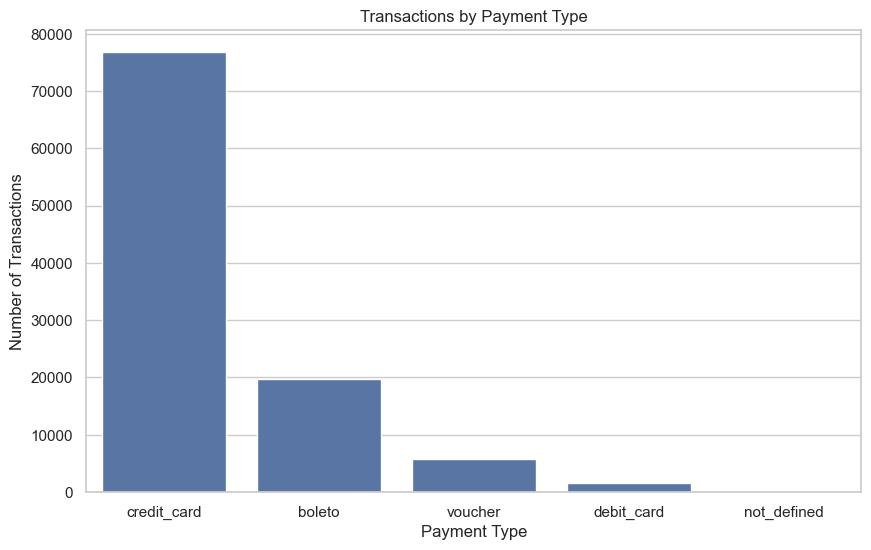

In [41]:
plt.figure(figsize=(10, 6))

# This creates a bar chart and automatically sorts it from highest to lowest
sns.countplot(data=payments_df, 
              x='payment_type', 
              order=payments_df['payment_type'].value_counts().index)

plt.title('Transactions by Payment Type')
plt.ylabel('Number of Transactions')
plt.xlabel('Payment Type')
plt.show()

### Detecting Outliers in Payment Values

Having observed a right-skewed distribution in our histogram, our next step is to specifically isolate and visualize the extreme high-value transactions. 

We use a Seaborn `boxplot` for this task. A boxplot calculates the interquartile range (the middle 50% of our data) and uses "whiskers" to show the boundary of typical spending. Any individual transactions that fall far outside those whiskers are plotted as individual points, clearly flagging them as outliers.

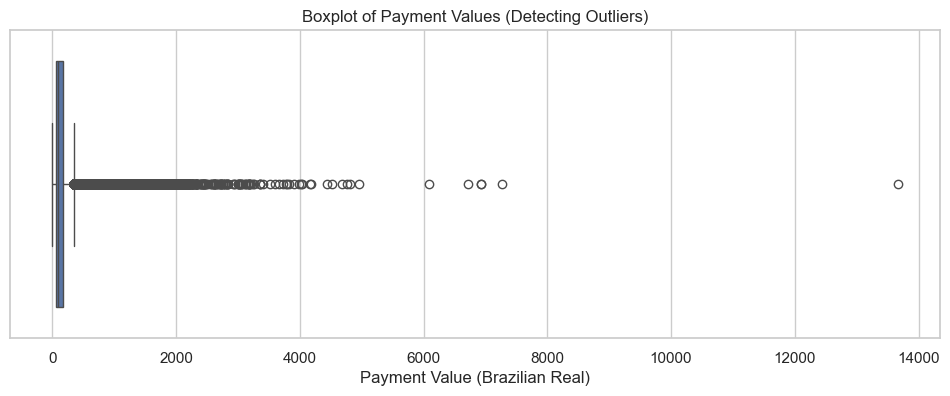

In [42]:
plt.figure(figsize=(12, 4))

# A boxplot is the best way to visualize outliers in numerical data
sns.boxplot(x=payments_df['payment_value'])

plt.title('Boxplot of Payment Values (Detecting Outliers)')
plt.xlabel('Payment Value (Brazilian Real)')
plt.show()

### Average Order Value (AOV) by Payment Method

Knowing that Credit Cards are the most frequent payment method, we now need to determine if they also drive higher revenue per transaction. To calculate the Average Order Value (AOV) for each payment method, we use a Seaborn `barplot`. 

Unlike a countplot, a barplot automatically calculates the mean (average) of the numeric `y` variable for each categorical `x` variable. We set `errorbar=None` to remove the default confidence interval lines, resulting in a cleaner, more readable chart.

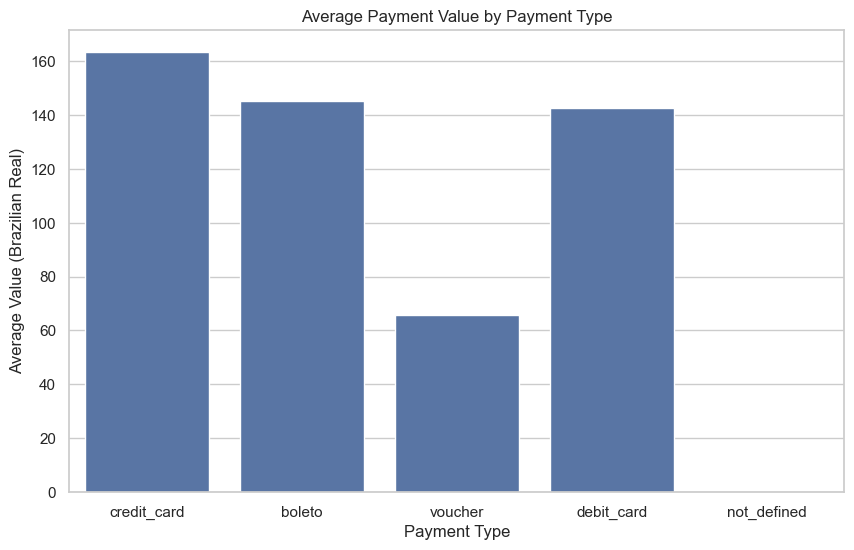

In [43]:
plt.figure(figsize=(10, 6))

# A barplot automatically calculates the average (mean) of the y-variable for each x-category
sns.barplot(data=payments_df, 
            x='payment_type', 
            y='payment_value', 
            errorbar=None) # errorbar=None hides the little black error lines for a cleaner look

plt.title('Average Payment Value by Payment Type')
plt.ylabel('Average Value (Brazilian Real)')
plt.xlabel('Payment Type')
plt.show()

### Analyzing Payment Installment Behavior

To understand *why* Credit Cards drive a significantly higher Average Order Value, we must look at regional purchasing behaviors. In the Brazilian e-commerce market, offering installment plans (parcelamento) is a major driver for high-value purchases.

We use a Seaborn `countplot` to visualize the distribution of the `payment_installments` column. This simple frequency chart will show us exactly how many transactions are paid entirely upfront versus split over multiple months.

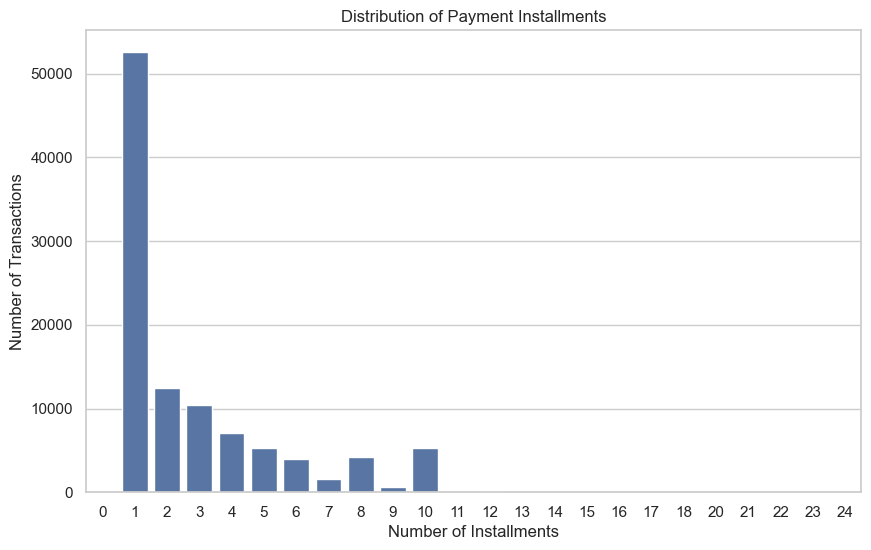

In [44]:
plt.figure(figsize=(10, 6))

# Countplot to see the most common number of installments
sns.countplot(data=payments_df, x='payment_installments')

plt.title('Distribution of Payment Installments')
plt.ylabel('Number of Transactions')
plt.xlabel('Number of Installments')
plt.show()

## Phase 3: Product & Category Analysis

Having analyzed overall sales health and payment behaviors, we now turn our attention to the actual products being sold. 

### Loading Relational Product Datasets

In professional e-commerce databases, information is stored relationally (split across multiple tables) to prevent redundancy. To understand product performance in English, we must load three separate puzzle pieces that we will later join together:

1. **Order Items Dataset:** Acts as the bridge connecting a specific `order_id` to a specific `product_id`.
2. **Products Dataset:** Contains the specific details about the item, including its category name (which is recorded natively in Portuguese).
3. **Translation Dataset:** A mapping file used to translate the Portuguese category names into English for our final analysis.

In [50]:
# 1. Load the items dataset (this connects orders to specific products)
items_df = pd.read_csv('Brazilian E-Commerce Public Dataset by Olist/olist_order_items_dataset.csv')

# 2. Load the products dataset (this has the actual category names)
products_df = pd.read_csv('Brazilian E-Commerce Public Dataset by Olist/olist_products_dataset.csv')

# 3. Load the translation file (so we can read the Portuguese categories in English!)
translation_df = pd.read_csv('Brazilian E-Commerce Public Dataset by Olist/product_category_name_translation.csv')

### Constructing the Master Product Dataset

To analyze which specific products generate the most revenue, we must merge our relational tables into a single master dataframe. We achieve this using the `pd.merge()` function, chaining our datasets together step-by-step using shared unique identifiers (keys).

* **Step 1 (Inner Join):** We link `payments_df` and `items_df` using the `order_id`. An `inner` join ensures we only keep records where an order has both a registered payment and listed items.
* **Step 2 (Inner Join):** We attach `products_df` using the `product_id` to bring in the product's physical dimensions and category name (in Portuguese).
* **Step 3 (Left Join):** Finally, we attach the `translation_df` using the `product_category_name`. We specifically use a `left` join here. This is a defensive data practice: if a Portuguese category is missing from our translation dictionary, a `left` join ensures we don't accidentally delete the entire product record; it simply leaves the English name as a NULL value.

In [51]:
# First, merge payments and items together using the 'order_id' they share
merged_df = pd.merge(payments_df, items_df, on='order_id', how='inner')

# Next, attach the product details using the 'product_id'
merged_df = pd.merge(merged_df, products_df, on='product_id', how='inner')

# Finally, attach the English translations
merged_df = pd.merge(merged_df, translation_df, on='product_category_name', how='left')

# Let's look at our massive new super-dataset!
display(merged_df.head(3))

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,19.53,casa_construcao,57.0,921.0,8.0,800.0,17.0,27.0,17.0,home_construction
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,7.39,automotivo,59.0,1274.0,2.0,150.0,16.0,6.0,11.0,auto
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,8.72,perfumaria,54.0,1536.0,2.0,250.0,20.0,8.0,21.0,perfumery


### Identifying Top Revenue-Generating Categories

Now that we have our unified master dataset, we can calculate total sales performance by product type. 

To achieve this, we use the Pandas `.groupby()` function to group our data by the English category name, and then calculate the `.sum()` of the payment values for each group. We sort these aggregated numbers from highest to lowest and slice out the Top 10. 

Finally, we visualize the results using a Seaborn `barplot`. We intentionally plot the categories on the y-axis to create a horizontal bar chart, which makes reading long category names much easier.

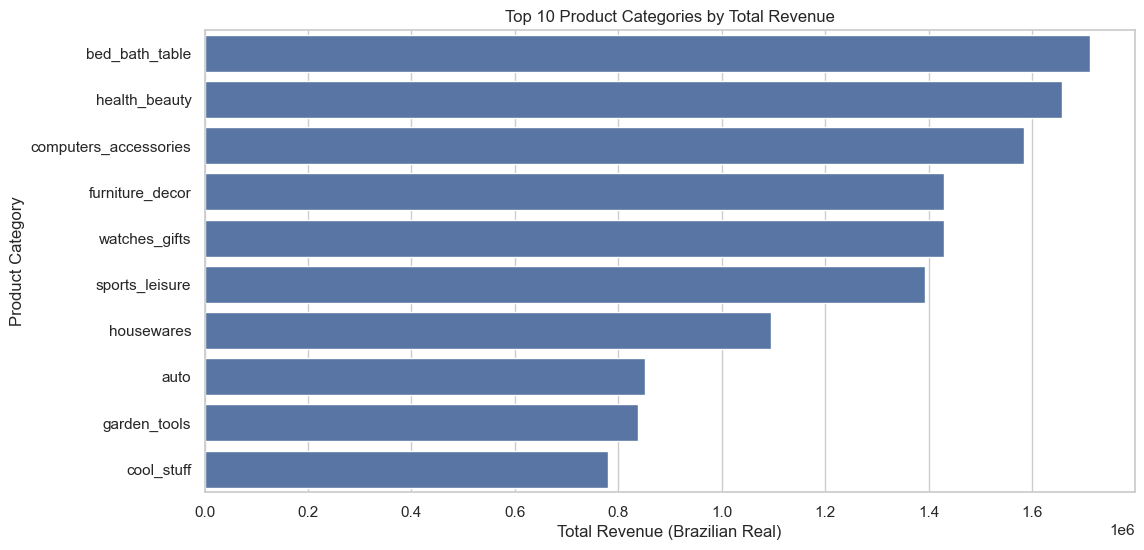

In [52]:
# Group by the English category name and add up all the payment values
category_revenue = merged_df.groupby('product_category_name_english')['payment_value'].sum()

# Sort them from highest to lowest and grab the top 10
top_10_categories = category_revenue.sort_values(ascending=False).head(10)

# Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_categories.values, y=top_10_categories.index)

plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('Total Revenue (Brazilian Real)')
plt.ylabel('Product Category')
plt.show()

## Phase 4: Temporal Analysis & Final Data Integration

To understand business growth and seasonal trends, we must integrate our transaction data with the original order timestamps. This step represents the final layer of our data integration, creating our "Ultimate Master DataFrame."

### Merging Timestamps and Feature Engineering

We perform two critical operations in this step:
1.  **Data Integration:** We merge our current `merged_df` with the `orders_df` using the `order_id`. This attaches the `order_purchase_timestamp` to every item and payment record.
2.  **Date-Time Conversion:** As identified in our initial audit, dates were loaded as text strings. We use `pd.to_datetime()` to convert these into proper Python `datetime` objects.
3.  **Feature Engineering:** We extract a `year_month` period from the timestamp. This "Feature Engineering" allows us to group tens of thousands of individual seconds into clean, monthly buckets for trend visualization.

In [53]:
# 1. Load the orders dataset to get the purchase dates
orders_df = pd.read_csv('Brazilian E-Commerce Public Dataset by Olist/olist_orders_dataset.csv')

# 2. Merge it into our existing data to create the ultimate Master DataFrame!
master_df = pd.merge(merged_df, orders_df, on='order_id', how='inner')

# 3. Convert the timestamp text into a proper Python 'Datetime' object
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

# 4. Extract just the Year and Month (e.g., 2017-08) so we can group by month
master_df['year_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# Verify it worked!
print("Data successfully merged! Total rows:", len(master_df))

Data successfully merged! Total rows: 117601


### Visualizing Monthly Revenue Trends
With our year_month features engineered, we can now analyze the temporal performance of the Olist platform. We use a Line Plot for this analysis because it is the industry-standard visualization for "Time-Series" data, allowing us to easily spot upward trends, downward dips, or recurring seasonal patterns.

We first aggregate the data using .groupby('year_month') and calculate the sum of payment_value. We then convert the index to strings to ensure the Matplotlib axis renders the dates clearly without formatting conflicts.

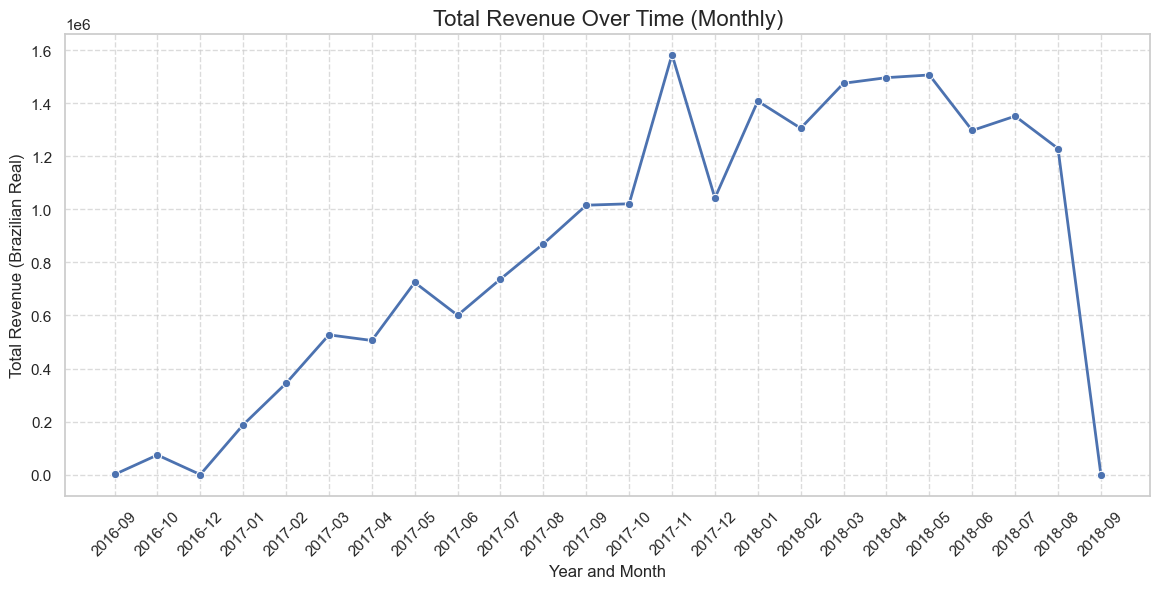

In [54]:
# Group by the Year-Month and add up the total revenue
monthly_revenue = master_df.groupby('year_month')['payment_value'].sum()

# Convert the index to simple text so the graph can read it easily
monthly_revenue.index = monthly_revenue.index.astype(str)

# Plotting the Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', linewidth=2)

plt.title('Total Revenue Over Time (Monthly)', fontsize=16)
plt.xlabel('Year and Month', fontsize=12)
plt.ylabel('Total Revenue (Brazilian Real)', fontsize=12)
plt.xticks(rotation=45) # Tilt the dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.7) # Add a light grid for readability
plt.show()